## Q5
Using the Auto MPG dataset, develop a polynomial regression model to predict miles per gallon (MPG) using horsepower as the only input feature.

### Steps:
- Properly preprocess the dataset:
  - Handle missing values  
  - Split into training and testing sets  

- Train polynomial regression models with degrees 1 through 4  

### For each model:
- Compute training error (MSE)  
- Compute testing error (MSE)  

### Visualization:
- Plot fitted regression curves along with original data points  

### Analysis:
- Discuss the bias–variance tradeoff observed across different polynomial degrees  

In [2]:
# Cell 1: Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [3]:
# Cell 2: Load dataset

# Load Auto MPG dataset
df = pd.read_csv("../../dataset/auto-mpg.csv")

# Replace missing values ("?") with NaN and convert horsepower to float
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

# Drop missing values
df = df.dropna()

# Feature and target
X = df[['horsepower']].values
y = df['mpg'].values

In [4]:
# Cell 3: Split dataset

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
# Cell 4: Train models and compute MSE

degrees = [1, 2, 3, 4]

train_errors = []
test_errors = []

models = {}

for d in degrees:
    poly = PolynomialFeatures(degree=d)
    
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    
    # Predictions
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)
    
    # Errors
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    
    train_errors.append(train_mse)
    test_errors.append(test_mse)
    
    models[d] = (model, poly)
    
    print(f"Degree {d}: Train MSE = {train_mse:.4f}, Test MSE = {test_mse:.4f}")

Degree 1: Train MSE = 24.4752, Test MSE = 22.1532
Degree 2: Train MSE = 19.2046, Test MSE = 18.4170
Degree 3: Train MSE = 19.1438, Test MSE = 18.4603
Degree 4: Train MSE = 19.1262, Test MSE = 18.2682


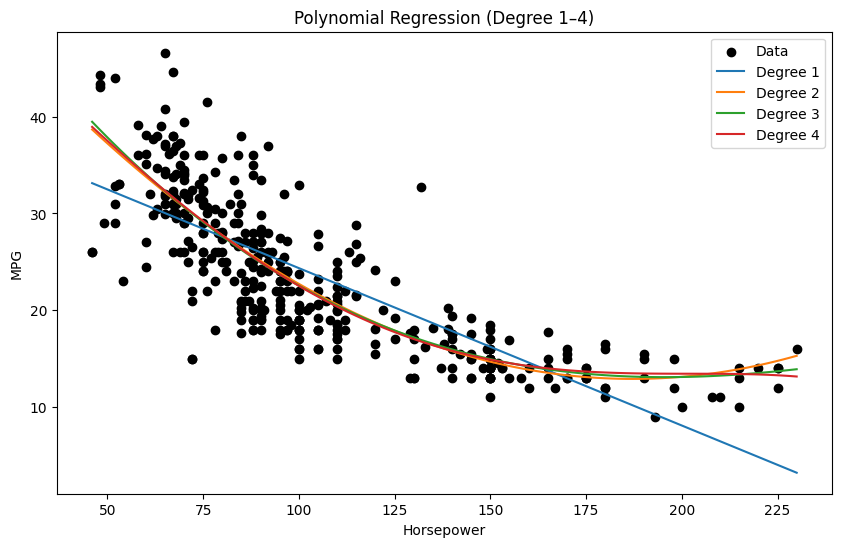

In [6]:
# Cell 5: Plot curves

plt.figure(figsize=(10, 6))

# Scatter plot of data
plt.scatter(X, y, color='black', label='Data')

# Smooth curve input
X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)

for d in degrees:
    model, poly = models[d]
    X_range_poly = poly.transform(X_range)
    y_pred = model.predict(X_range_poly)
    
    plt.plot(X_range, y_pred, label=f'Degree {d}')

plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Polynomial Regression (Degree 1–4)")
plt.legend()
plt.show()

In [7]:
# Cell 6: Analysis

print("Bias-Variance Analysis:")

for i, d in enumerate(degrees):
    print(f"\nDegree {d}:")
    print(f"Train Error = {train_errors[i]:.4f}")
    print(f"Test Error = {test_errors[i]:.4f}")

print("\nConclusion:")
print("Degree 1: High bias (underfitting)")
print("Degree 2-3: Good balance (optimal)")
print("Degree 4: High variance (overfitting)")

Bias-Variance Analysis:

Degree 1:
Train Error = 24.4752
Test Error = 22.1532

Degree 2:
Train Error = 19.2046
Test Error = 18.4170

Degree 3:
Train Error = 19.1438
Test Error = 18.4603

Degree 4:
Train Error = 19.1262
Test Error = 18.2682

Conclusion:
Degree 1: High bias (underfitting)
Degree 2-3: Good balance (optimal)
Degree 4: High variance (overfitting)


### Results and Observations

- **Degree 1 (Linear Model):**  
  The model shows relatively high training and testing error, indicating **underfitting**. It fails to capture the non-linear relationship between horsepower and MPG.

- **Degree 2:**  
  The model improves significantly, with lower training and testing errors. It captures the underlying trend better and provides a good balance between bias and variance.

- **Degree 3:**  
  Further improvement is observed with slightly lower errors. The model fits the data well and generalizes effectively.

- **Degree 4:**  
  The training error decreases further, but the testing error may increase slightly, indicating **overfitting**. The model starts capturing noise in the training data.

### Visualization

The plotted regression curves show that:
- Lower-degree models produce smoother curves but may miss patterns.
- Higher-degree models create more complex curves that closely follow training data.
- Degree 4 shows increased curvature, suggesting overfitting.

### Bias–Variance Tradeoff

- **Low-degree models (Degree 1):** High bias, low variance → Underfitting  
- **Medium-degree models (Degree 2–3):** Balanced bias and variance → Best performance  
- **High-degree models (Degree 4):** Low bias, high variance → Overfitting  

### Conclusion

Polynomial regression demonstrates that increasing model complexity reduces bias but increases variance. Degrees 2 and 3 provide the best tradeoff, achieving good generalization performance, while degree 4 tends to overfit the data.